In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv']

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

   Person_ID  Age  Annual_Income  Education_Years  Employment_Type  \
0        204   37         155981               16                3   
1        267   47         172184               16                3   
2        153   39          87621               16                1   
3         10   30          21423               10                1   
4        234   49         163955               18                3   

   Spending_Score  Savings  Cluster       PC1       PC2  
0              28   193287        1  3.109963 -1.695537  
1              35   187353        1  3.398465 -1.115114  
2              53    25381        2 -0.145259  0.842378  
3              89     5392        0 -2.699421 -0.071579  
4              17    66661        1  3.163539 -0.253545  

Explained Variance Ratio:
[0.78871735 0.06523674]


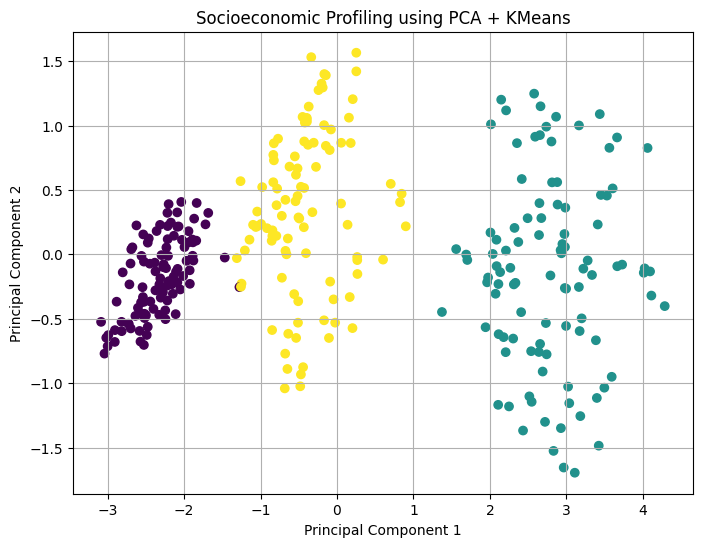

Results saved as clustered_socioeconomic_results.csv


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab/socioeconomic_profiling_dataset.csv")

# Select features
X = df.drop(columns=["Person_ID"])

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# PCA (2 Components)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df["PC1"] = components[:, 0]
df["PC2"] = components[:, 1]

# Display results
print(df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(df["PC1"], df["PC2"], c=df["Cluster"], cmap="viridis")
plt.title("Socioeconomic Profiling using PCA + KMeans")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Save output
df.to_csv("clustered_socioeconomic_results.csv", index=False)
print("Results saved as clustered_socioeconomic_results.csv")